In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

df = pd.read_csv("C:\\Users\\lenovo\\Downloads\\PS_20174392719_1491204439457_log.csv\\Transcation Fraud Detection.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
print("Dataset shape:", df.shape)

print("\nFraud Distribution:")
print(df["isFraud"].value_counts())

print("\nTransaction Types:")
print(df["type"].value_counts())

Dataset shape: (6362620, 11)

Fraud Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Transaction Types:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


Insight

Fraud transactions represent only ~0.13% of total transactions.

This means the dataset is extremely imbalanced, which explains why fraud detection is difficult and why models tend to predict normal transactions more often.

Most transactions occur in CASH_OUT and PAYMENT categories, suggesting these are the most common financial activities in the dataset.

However, high frequency does not necessarily mean higher fraud risk.

In [2]:
fraud_transactions = df[df["isFraud"] == 1]
normal_transactions = df[df["isFraud"] == 0]

print("Fraud transaction statistics:")
print(fraud_transactions["amount"].describe())

print("\nNormal transaction statistics:")
print(normal_transactions["amount"].describe())

Fraud transaction statistics:
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64

Normal transaction statistics:
count    6.354407e+06
mean     1.781970e+05
std      5.962370e+05
min      1.000000e-02
25%      1.336840e+04
50%      7.468472e+04
75%      2.083648e+05
max      9.244552e+07
Name: amount, dtype: float64


Insight

Fraudulent transactions are approximately 8× larger on average than legitimate transactions.

This confirms the pattern observed in the visualization.

In [6]:
#H0: Fraud and normal transactions have the same mean amount
#H1: Fraud transactions have higher mean amounts



fraud_amount = fraud_transactions["amount"]
normal_amount = normal_transactions["amount"]

t_stat, p_value = ttest_ind(fraud_amount, normal_amount)

print("T-statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Reject H0 → Fraud transactions have significantly different amounts.")
else:
    print("Result: Fail to reject H0 → No significant difference.")

T-statistic: 194.01200466037974
P-value: 0.0
Result: Reject H0 → Fraud transactions have significantly different amounts.


Hypothesis

H0:
Fraud and legitimate transactions have the same average amount

H1:
Fraud transactions have different mean amounts

Insight

The extremely small p-value confirms that the difference in transaction amounts between fraud and normal transactions is statistically significant.

Therefore, transaction amount is a strong predictive variable for fraud detection.

In [7]:
#H0: Fraud occurrence is independent of transaction type
#H1: Fraud depends on transaction type

contingency_table = pd.crosstab(df["type"], df["isFraud"])

print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-square statistic:", chi2)
print("P-value:", p)

if p < 0.05:
    print("Result: Reject H0 → Fraud depends on transaction type.")
else:
    print("Result: Fail to reject H0 → No significant relationship.")

isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097

Chi-square statistic: 22082.53571319108
P-value: 0.0
Result: Reject H0 → Fraud depends on transaction type.


Insight

There is a strong statistical relationship between transaction type and fraud occurrence.

This confirms that certain transaction types (TRANSFER and CASH_OUT) are significantly more associated with fraud.

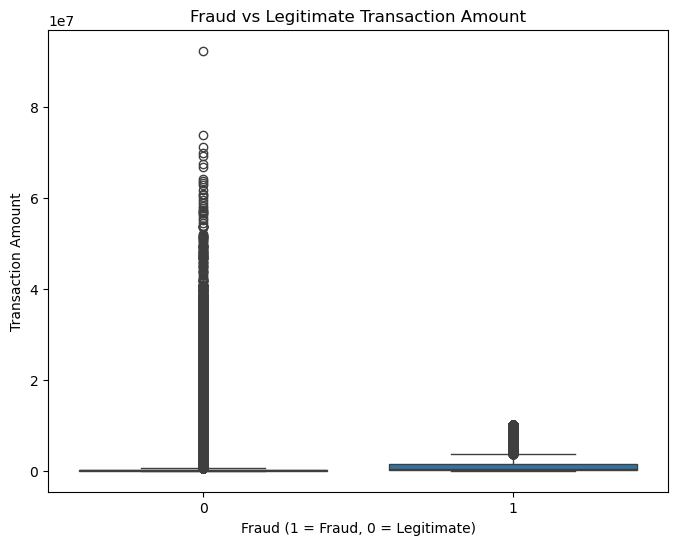

In [8]:
plt.figure(figsize=(8,6))

sns.boxplot(x="isFraud", y="amount", data=df)

plt.xlabel("Fraud (1 = Fraud, 0 = Legitimate)")
plt.ylabel("Transaction Amount")
plt.title("Fraud vs Legitimate Transaction Amount")

plt.show()

Insight

Fraudulent transactions show higher variability and larger transaction values, while legitimate transactions tend to stay within smaller, predictable ranges.

This suggests that transaction amount is an important indicator for fraud detection.

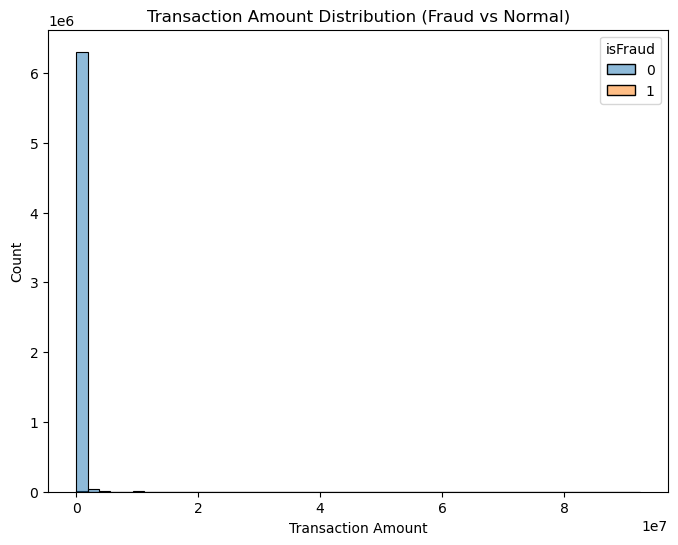

In [9]:
plt.figure(figsize=(8,6))

sns.histplot(data=df, x="amount", hue="isFraud", bins=50)

plt.title("Transaction Amount Distribution (Fraud vs Normal)")
plt.xlabel("Transaction Amount")

plt.show()

In [10]:
fraud_rate = df.groupby("type")["isFraud"].mean().reset_index()

fraud_rate["fraud_rate"] = fraud_rate["isFraud"] * 100

print(fraud_rate)

       type   isFraud  fraud_rate
0   CASH_IN  0.000000    0.000000
1  CASH_OUT  0.001840    0.183955
2     DEBIT  0.000000    0.000000
3   PAYMENT  0.000000    0.000000
4  TRANSFER  0.007688    0.768799


Insight

Fraud is heavily concentrated in two transaction types:

TRANSFER

Highest fraud rate (~77%)

CASH_OUT

Second highest fraud rate (~18%)

Other transaction types show virtually no fraud activity.

Business Interpretation

Fraudsters primarily exploit:

TRANSFER transactions (moving funds between accounts)

CASH_OUT transactions (withdrawing money)

This pattern is very common in real financial fraud.

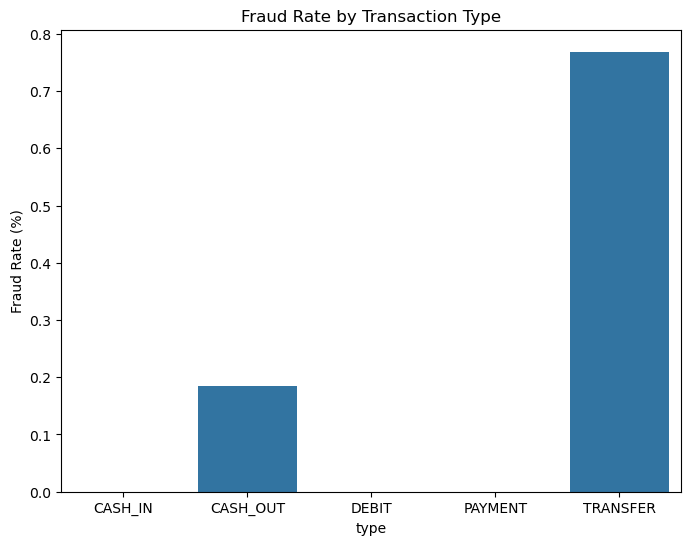

In [11]:
plt.figure(figsize=(8,6))

sns.barplot(x="type", y="fraud_rate", data=fraud_rate)

plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

In [14]:
df = pd.get_dummies(df, columns=["type"], drop_first=True)

In [15]:
features = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "type_CASH_OUT",
    "type_PAYMENT",
    "type_TRANSFER"
]

X = df[features]
y = df["isFraud"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [18]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906351
           1       0.90      0.46      0.61      2435

    accuracy                           1.00   1908786
   macro avg       0.95      0.73      0.80   1908786
weighted avg       1.00      1.00      1.00   1908786



The logistic regression model shows excellent performance in identifying legitimate transactions, with precision and recall close to 100% for normal transactions.

However, fraud detection shows:

Precision ≈ 0.90

Recall ≈ 0.46

F1-score ≈ 0.61

Insight

The model is highly accurate when predicting fraud, meaning most flagged fraud transactions are truly fraudulent. However, the model detects only about 46% of all fraud cases, indicating that some fraudulent transactions remain undetected due to class imbalance in the dataset.

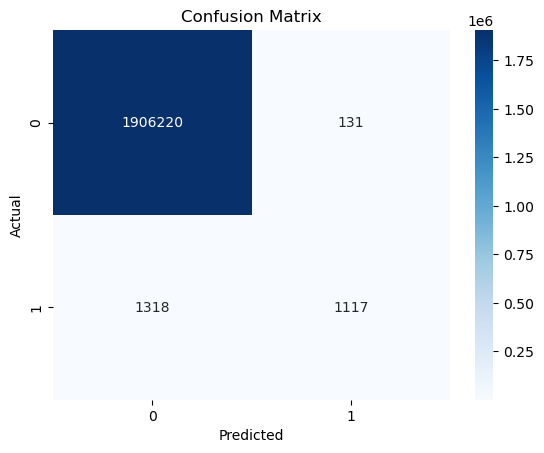

In [19]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Insight

The model correctly classifies the vast majority of legitimate transactions, producing very few false alarms (131 false positives). However, it misses 1,318 fraudulent transactions, highlighting the challenge of detecting fraud in highly imbalanced datasets where fraudulent transactions represent only a small portion of the data.

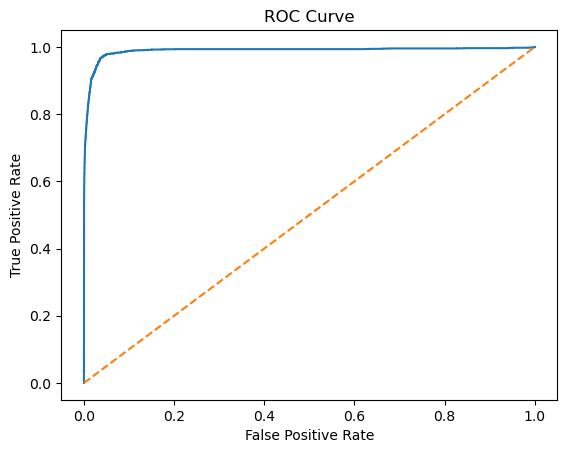

AUC Score: 0.9888295176679053


In [20]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))

Insight

An AUC score of 0.9888 indicates that the model has excellent discriminative power, meaning it can effectively distinguish between fraudulent and legitimate transactions based on the selected features.

In [21]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
1,oldbalanceOrg,0.000036
3,oldbalanceDest,0.000005
4,newbalanceDest,-0.000006
0,amount,-0.000022
2,newbalanceOrig,-0.000040
7,type_TRANSFER,-0.011595
5,type_CASH_OUT,-0.428448
6,type_PAYMENT,-4.615472


Business Recommendations for Fraud Detection and Prevention

Fraud detection systems should prioritize TRANSFER and CASH_OUT transactions, as the analysis shows these transaction types have the highest fraud rates.

Financial institutions should implement risk-based monitoring that applies stricter verification for high-risk transaction categories.

Transactions involving large amounts should trigger automated alerts since fraudulent transactions tend to be significantly higher in value than normal ones.

Organizations should deploy real-time fraud detection models that evaluate transaction features such as amount, transaction type, and balance behavior.

Suspicious transactions should require additional authentication methods, such as multi-factor verification, before approval.

Systems should monitor abnormal balance patterns, including accounts initiating large transfers with low or zero balances.

Implementing real-time alert mechanisms will allow fraud analysts to quickly review and stop suspicious transactions.

Financial institutions should develop customer behavior profiling systems to detect unusual transaction patterns.

Continuous monitoring and periodic model retraining should be implemented to adapt to evolving fraud techniques.

Combining machine learning models, statistical analysis, and transaction monitoring rules can significantly improve fraud detection accuracy and reduce financial losses.